In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# 🔹 Prunable Linear Layer
# =========================
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.02)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # gate scores (raw values)
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        # sharper sigmoid
        gates = torch.sigmoid(25 * self.gate_scores)

        if self.training:
            pruned_weights = self.weight * gates
        else:
            # hard pruning during eval
            hard_gates = (gates > 0.1).float()
            pruned_weights = self.weight * hard_gates

        return F.linear(x, pruned_weights, self.bias)

    def get_gate_values(self):
        return torch.sigmoid(10 * self.gate_scores)


# =========================
# 🔹 Model
# =========================
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

    # for sparsity loss (IMPORTANT)
    def get_all_gate_scores(self):
        scores = []
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                scores.append(m.gate_scores.view(-1))
        return torch.cat(scores)

    # for evaluation
    def get_all_gates(self):
        gates = []
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                gates.append(m.get_gate_values().view(-1))
        return torch.cat(gates)


# =========================
# 🔹 Loss
# =========================
def sparsity_loss(model):
    # L1 on RAW scores (stronger signal)
    return torch.mean(torch.abs(model.get_all_gate_scores()) ** 1.5)


# =========================
# 🔹 Sparsity Metric
# =========================
def compute_sparsity(model, threshold=0.1):
    gates = model.get_all_gates().detach().cpu().numpy()
    total = gates.size
    pruned = np.sum(gates < threshold)
    return 100.0 * pruned / total


# =========================
# 🔹 Data
# =========================
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


# =========================
# 🔹 Training
# =========================
def train_model(lambda_val, epochs=10):
    model = PrunableNet().to(device)

    # different LR for gates (important)
    gate_params = []
    weight_params = []

    for name, param in model.named_parameters():
        if "gate_scores" in name:
            gate_params.append(param)
        else:
            weight_params.append(param)

    optimizer = optim.Adam([
        {"params": weight_params, "lr": 1e-3},
        {"params": gate_params, "lr": 5e-3}
    ])

    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()

            output = model(data)
            cls_loss = criterion(output, target)

            # warmup (first 2 epochs no pruning)
            if epoch < 2:
                loss = cls_loss
            else:
                sp_loss = sparsity_loss(model)
                loss = cls_loss + lambda_val * sp_loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # DEBUG (important)
        gates = model.get_all_gates().detach().cpu().numpy()
        print(f"[λ={lambda_val}] Epoch {epoch+1} | Loss={total_loss:.2f} | GateMean={gates.mean():.4f}")

    return model


# =========================
# 🔹 Evaluation
# =========================
def evaluate(model):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)

            output = model(data)
            pred = output.argmax(dim=1)

            correct += (pred == target).sum().item()
            total += target.size(0)

    acc = 100.0 * correct / total
    sparsity = compute_sparsity(model)

    return acc, sparsity


# =========================
# 🔹 Experiments
# =========================
lambdas = [0.01, 0.1, 0.5]
results = []

for lam in lambdas:
    print(f"\n🚀 Training with lambda = {lam}")
    model = train_model(lam, epochs=8)

    acc, sparsity = evaluate(model)

    print(f"✅ Lambda: {lam} | Accuracy: {acc:.2f}% | Sparsity: {sparsity:.2f}%")
    results.append((lam, acc, sparsity))


# =========================
# 🔹 Final Table
# =========================
print("\n📊 Final Results:")
print("Lambda\tAccuracy\tSparsity")

for r in results:
    print(f"{r[0]}\t{r[1]:.2f}%\t\t{r[2]:.2f}%")


🚀 Training with lambda = 0.01
[λ=0.01] Epoch 1 | Loss=736.06 | GateMean=0.4966
[λ=0.01] Epoch 2 | Loss=654.91 | GateMean=0.4930
[λ=0.01] Epoch 3 | Loss=618.05 | GateMean=0.4875
[λ=0.01] Epoch 4 | Loss=593.57 | GateMean=0.4792
[λ=0.01] Epoch 5 | Loss=574.13 | GateMean=0.4737
[λ=0.01] Epoch 6 | Loss=559.71 | GateMean=0.4691
[λ=0.01] Epoch 7 | Loss=547.09 | GateMean=0.4653
[λ=0.01] Epoch 8 | Loss=534.58 | GateMean=0.4621
✅ Lambda: 0.01 | Accuracy: 49.44% | Sparsity: 17.90%

🚀 Training with lambda = 0.1
[λ=0.1] Epoch 1 | Loss=733.25 | GateMean=0.4957
[λ=0.1] Epoch 2 | Loss=653.80 | GateMean=0.4923
[λ=0.1] Epoch 3 | Loss=621.86 | GateMean=0.4825
[λ=0.1] Epoch 4 | Loss=591.77 | GateMean=0.4780
[λ=0.1] Epoch 5 | Loss=575.12 | GateMean=0.4738
[λ=0.1] Epoch 6 | Loss=557.60 | GateMean=0.4707
[λ=0.1] Epoch 7 | Loss=544.87 | GateMean=0.4678
[λ=0.1] Epoch 8 | Loss=530.18 | GateMean=0.4648
✅ Lambda: 0.1 | Accuracy: 50.37% | Sparsity: 11.24%

🚀 Training with lambda = 0.5
[λ=0.5] Epoch 1 | Loss=740.3

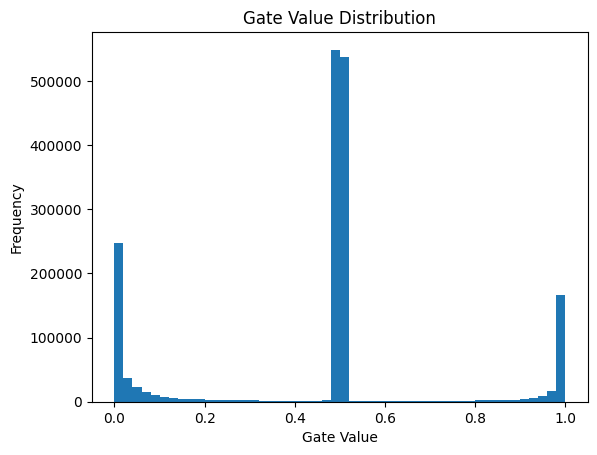

In [12]:
import matplotlib.pyplot as plt

gates = model.get_all_gates().detach().cpu().numpy()

plt.hist(gates, bins=50)
plt.title("Gate Value Distribution")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()